In [ ]:
!pip install emoji
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import emoji

from sklearn.naive_bayes import ComplementNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix



from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB


import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)



In [ ]:
df = pd.read_csv("data.csv")

# **PART 01 :**

# **1. Data Exploration & Distribution Analysis :**

In [ ]:
sns.set(style="whitegrid")

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nLabel distribution (normalized):")
print(df['Generic Class'].value_counts(normalize=True))

print("\nDialect distribution:")
print(df['Dialect'].value_counts())


Dataset shape: (7383, 5)

Columns: ['Text', 'Generic Class', 'Original class', 'Source', 'Dialect']

Label distribution (normalized):
Generic Class
non-offensive    0.793309
offensive        0.206691
Name: proportion, dtype: float64

Dialect distribution:
Dialect
DZ    4249
LB    3134
Name: count, dtype: int64


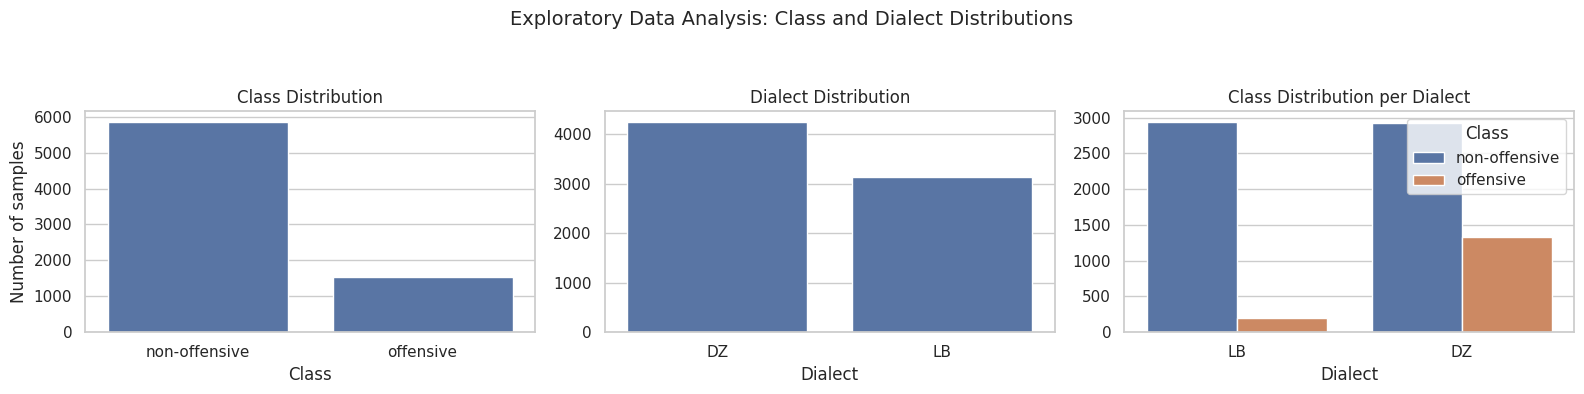

In [ ]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1️⃣ Class distribution
sns.countplot(
    data=df,
    x='Generic Class',
    order=df['Generic Class'].value_counts().index,
    ax=axes[0]
)
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of samples")

# 2️⃣ Dialect distribution
sns.countplot(
    data=df,
    x='Dialect',
    order=df['Dialect'].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("Dialect Distribution")
axes[1].set_xlabel("Dialect")
axes[1].set_ylabel("")

# 3️⃣ Class distribution per dialect
sns.countplot(
    data=df,
    x='Dialect',
    hue='Generic Class',
    ax=axes[2]
)
axes[2].set_title("Class Distribution per Dialect")
axes[2].set_xlabel("Dialect")
axes[2].set_ylabel("")
axes[2].legend(title="Class")

# Global title for the section
fig.suptitle("Exploratory Data Analysis: Class and Dialect Distributions", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


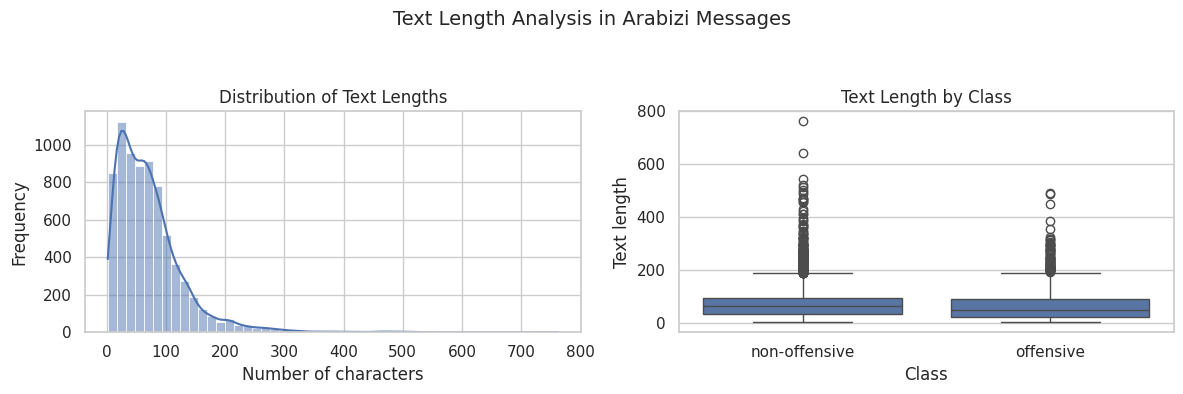

In [ ]:
# Make sure your text column is named correctly, e.g., 'text'
df['text_length'] = df['Text'].apply(len)
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1️⃣ Distribution of text lengths
sns.histplot(
    df['text_length'],
    bins=50,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribution of Text Lengths")
axes[0].set_xlabel("Number of characters")
axes[0].set_ylabel("Frequency")

# 2️⃣ Text length by class
sns.boxplot(
    data=df,
    x='Generic Class',
    y='text_length',
    ax=axes[1]
)
axes[1].set_title("Text Length by Class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Text length")

# Global title
fig.suptitle("Text Length Analysis in Arabizi Messages", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


**Examples**

In [ ]:
df[df['Generic Class'] == 'non-offensive'].sample(7)[['Text', 'Dialect']]


,Text,Dialect
828,@Tarek_Omran hahaha ehh hayda el zinikh fiya,LB
4426,Hhh 7na fi tlm ki yjiw ydiro l3ars bsimana 9ba...,DZ
935,@WizKhalifaSquad @Nadiakhairallah fhamie ktir ...,LB
2851,Kholsit ltweet w ente mabsouta so z3elet,LB
4354,hadi f porsay tedkholha b glisseur wla zodiaqu...,DZ
7298,sewantemoklijabtek,DZ
4600,Hhhhhhh aya gawriya b khatam ta3e fada w nta t...,DZ


# **2. Data Preparation – Robust Text Cleaning**

In [ ]:
def clean_text(text):
    text = str(text).lower()

    # Convert emojis to text (😡 -> angry_face)
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove mentions and hashtags
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)

    # Replace emoji descriptions formatting
    # face_with_tears_of_joy -> face with tears of joy
    text = re.sub(r"_", " ", text)
    text = re.sub(r":", " ", text)

    # Keep Arabizi characters, digits, ! ?
    text = re.sub(r"[^a-z0-9\s!?]", " ", text)

    # Normalize repeated punctuation
    text = re.sub(r"!{2,}", "!", text)
    text = re.sub(r"\?{2,}", "?", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


In [ ]:
df['clean_text'] = df['Text'].apply(clean_text)

df[['Text', 'clean_text']][5:10]


,Text,clean_text
5,Hayda ensen marid,hayda ensen marid
6,my uncle is lowkey aawne w ktir aabele natfo,my uncle is lowkey aawne w ktir aabele natfo
7,Hmar mn Lebnen. Roo7 ballit l ba7r 😂,hmar mn lebnen roo7 ballit l ba7r face with te...
8,Rou2 noss se3a bro bkhaliss ma emmak bkaffeh m...,rou2 noss se3a bro bkhaliss ma emmak bkaffeh m...
9,Morda ento 3njd!😂 alla yechfikon 🍊 At least fh...,morda ento 3njd! face with tears of joy alla y...


# **PART 02:**

In [ ]:
# Features, labels, and dialects
X = df['clean_text']
y = df['Generic Class']
dialects = df['Dialect']

# Step 1: Train/Test split (FINAL test set)
X_train_full, X_test, y_train_full, y_test, dialect_train_full, dialect_test = train_test_split(
    X,
    y,
    dialects,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Step 2: Train/Validation split (from training only)
X_train, X_val, y_train, y_val, dialect_train, dialect_val = train_test_split(
    X_train_full,
    y_train_full,
    dialect_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

y_test_models = y_test.copy()
# ✅ Store dialects for later use
print("Train label distribution:\n", y_train.value_counts(normalize=True))
print("Validation label distribution:\n", y_val.value_counts(normalize=True))
print("Test label distribution:\n", y_test.value_counts(normalize=True))


Train label distribution:
 Generic Class
non-offensive    0.793184
offensive        0.206816
Name: proportion, dtype: float64
Validation label distribution:
 Generic Class
non-offensive    0.79357
offensive        0.20643
Name: proportion, dtype: float64
Test label distribution:
 Generic Class
non-offensive    0.7935
offensive        0.2065
Name: proportion, dtype: float64


In [ ]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),  # Word unigrams and bigrams
    min_df=3,  # Minimum document frequency for a word
    max_df=0.9,  # Maximum document frequency
    sublinear_tf=True,  # Apply sublinear scaling to term frequency
    max_features=50000,
    # Removed stop_words='english' - not appropriate for Arabizi
)

# Fit on the training data only
vectorizer.fit(X_train_full)

# Transform all datasets
X_train_full_tfidf = vectorizer.transform(X_train_full)
X_train_tfidf = vectorizer.transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF train full shape:", X_train_full_tfidf.shape)
print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF val shape:", X_val_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train full shape: (5906, 4300)
TF-IDF train shape: (4724, 4300)
TF-IDF val shape: (1182, 4300)
TF-IDF test shape: (1477, 4300)


**For error analysis**

In [ ]:
y_train_full_error = y_train_full.copy()
y_train_error = y_train.copy()
y_val_error = y_val.copy()
y_test_error = y_test.copy()

In [ ]:
# Define your models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Multinomial NB": MultinomialNB(),
    "Complement NB": ComplementNB(),
    "SVM (Linear)": SVC(kernel='linear', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

In [ ]:
results = {}
Y_preds_val = {}

for name, model in models.items():
    # Train on TRAIN
    model.fit(X_train_tfidf, y_train)

    # Predict on VALIDATION
    y_val_pred = model.predict(X_val_tfidf)

    # Metrics (VALIDATION)
    acc = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred, average=None, zero_division=0)
    rec = recall_score(y_val, y_val_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_val, y_val_pred, average=None, zero_division=0)
    f1_macro = f1_score(y_val, y_val_pred, average='macro', zero_division=0)

    results[name] = {
        "Accuracy": acc,
        "Precision per class": prec,
        "Recall per class": rec,
        "F1 per class": f1_per_class,
        "F1 Macro": f1_macro
    }

    Y_preds_val[name] = y_val_pred

    print(f"=== {name} (Validation) ===")
    print(classification_report(y_val, y_val_pred, zero_division=0))
    print("Macro F1:", f1_macro)
    print("\n")

comparison_df = pd.DataFrame(results).T
comparison_df


=== Logistic Regression (Validation) ===
               precision    recall  f1-score   support

non-offensive       0.83      0.99      0.91       938
    offensive       0.91      0.24      0.38       244

     accuracy                           0.84      1182
    macro avg       0.87      0.62      0.64      1182
 weighted avg       0.85      0.84      0.80      1182

Macro F1: 0.6444664918621407


=== Multinomial NB (Validation) ===
               precision    recall  f1-score   support

non-offensive       0.84      0.99      0.91       938
    offensive       0.88      0.27      0.41       244

     accuracy                           0.84      1182
    macro avg       0.86      0.63      0.66      1182
 weighted avg       0.85      0.84      0.81      1182

Macro F1: 0.6611752803304949


=== Complement NB (Validation) ===
               precision    recall  f1-score   support

non-offensive       0.90      0.79      0.84       938
    offensive       0.45      0.64      0.53     

,Accuracy,Precision per class,Recall per class,F1 per class,F1 Macro
Logistic Regression,0.838409,"[0.8343777976723367, 0.9076923076923077]","[0.9936034115138592, 0.24180327868852458]","[0.9070559610705596, 0.3818770226537217]",0.644466
Multinomial NB,0.841794,"[0.8392050587172538, 0.88]","[0.990405117270789, 0.27049180327868855]","[0.908557457212714, 0.41379310344827586]",0.661175
Complement NB,0.761421,"[0.8951807228915662, 0.4460227272727273]","[0.7921108742004265, 0.6434426229508197]","[0.8404977375565611, 0.5268456375838926]",0.683672
SVM (Linear),0.853638,"[0.8564771668219944, 0.8256880733944955]","[0.9797441364605544, 0.36885245901639346]","[0.9139731476877175, 0.509915014164306]",0.711944
Random Forest,0.844332,"[0.8563327032136105, 0.7419354838709677]","[0.9658848614072495, 0.3770491803278688]","[0.9078156312625251, 0.5]",0.703908


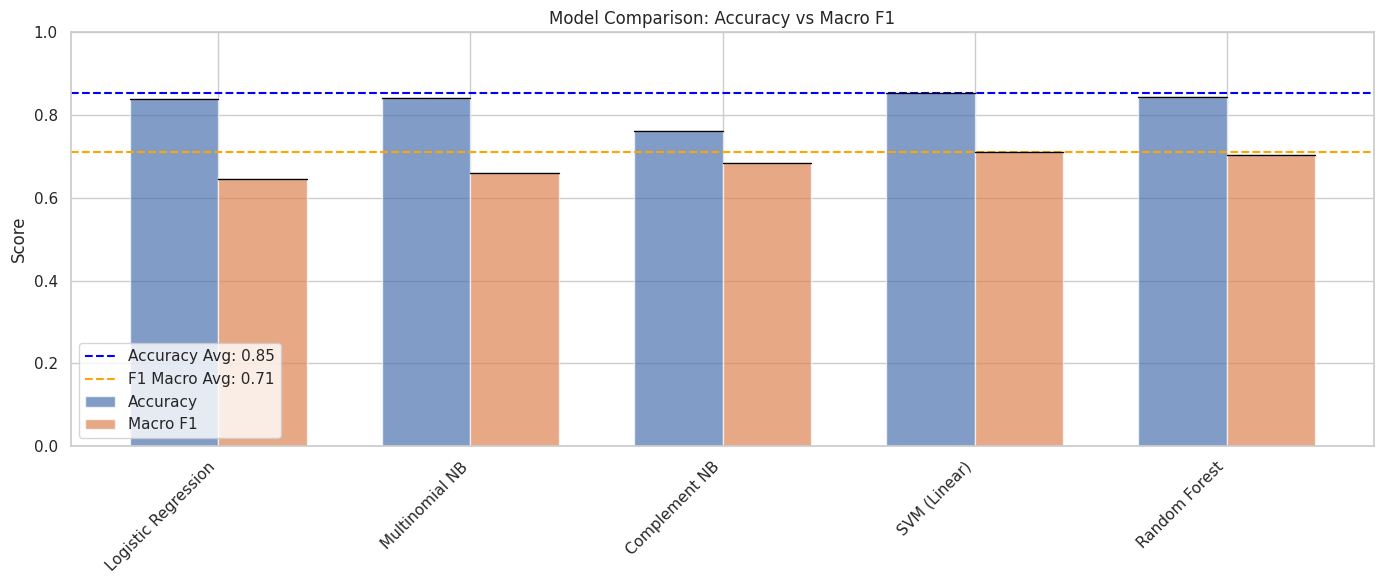

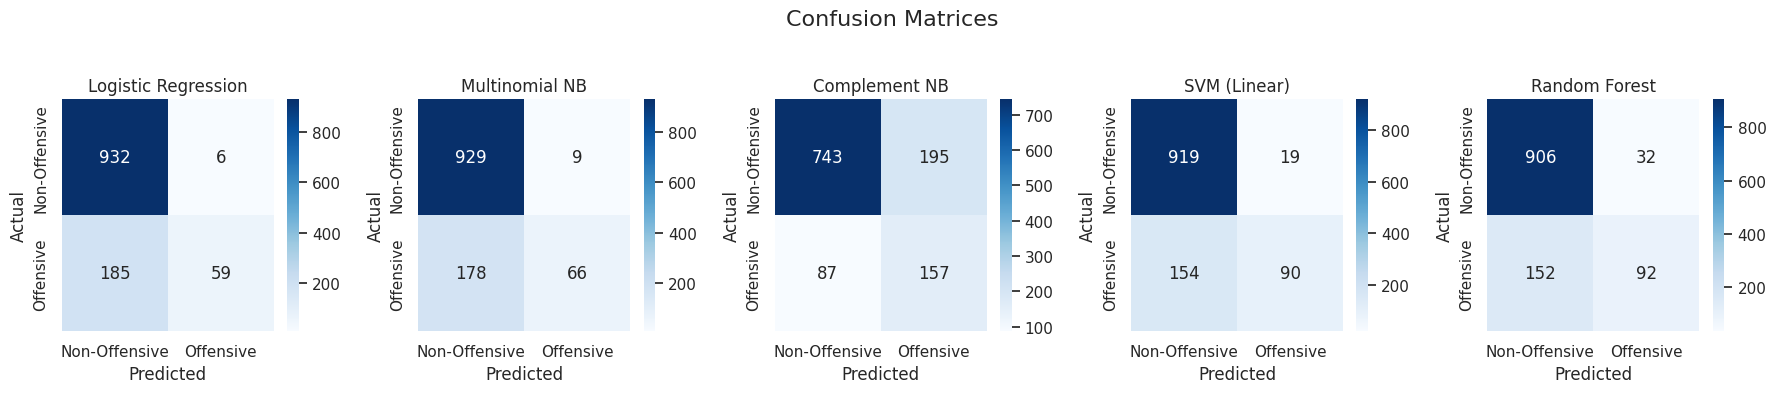

In [ ]:
metrics_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[m]["Accuracy"] for m in results],
    "Macro F1": [results[m]["F1 Macro"] for m in results]
})

# Add dashed lines for each metric (average as reference)
accuracy_SVM = comparison_df['Accuracy']['SVM (Linear)']
f1_macro_SVM = comparison_df['F1 Macro']['SVM (Linear)']

plt.figure(figsize=(14,6))
bar_width = 0.35
index = np.arange(len(metrics_df))

plt.axhline(y=accuracy_SVM, color='blue', linestyle='--', label=f'Accuracy Avg: {accuracy_SVM:.2f}')
plt.axhline(y=f1_macro_SVM, color='orange', linestyle='--', label=f'F1 Macro Avg: {f1_macro_SVM:.2f}')

# Bars
acc_bars = plt.bar(index, metrics_df["Accuracy"], bar_width, label="Accuracy", alpha=0.7)
f1_bars = plt.bar(index + bar_width, metrics_df["Macro F1"], bar_width, label="Macro F1", alpha=0.7)

# Add line on top of bars to highlight differences
for bar in acc_bars:
    plt.plot([bar.get_x(), bar.get_x() + bar.get_width()], [bar.get_height(), bar.get_height()], color='black', linewidth=1)
for bar in f1_bars:
    plt.plot([bar.get_x(), bar.get_x() + bar.get_width()], [bar.get_height(), bar.get_height()], color='black', linewidth=1)

plt.xticks(index + bar_width/2, metrics_df["Model"], rotation=45, ha="right")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Comparison: Accuracy vs Macro F1")
plt.legend()
plt.tight_layout()
plt.show()

# 2️⃣ Confusion matrices in subplots
fig, axes = plt.subplots(1, len(models), figsize=(18,4))
fig.suptitle("Confusion Matrices", fontsize=16)

for ax, (name, model) in zip(axes, models.items()):
    y_pred = Y_preds_val[name]
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-Offensive","Offensive"],
                yticklabels=["Non-Offensive","Offensive"],
                ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**Train best model on TRAIN + VAL**

In [ ]:
best_model = models["SVM (Linear)"]

best_model.fit(X_train_full_tfidf, y_train_full)

y_test_pred = best_model.predict(X_test_tfidf)

print("FINAL TEST RESULTS")
print(classification_report(y_test, y_test_pred, zero_division=0))


FINAL TEST RESULTS
               precision    recall  f1-score   support

non-offensive       0.85      0.98      0.91      1172
    offensive       0.79      0.31      0.45       305

     accuracy                           0.84      1477
    macro avg       0.82      0.64      0.68      1477
 weighted avg       0.83      0.84      0.81      1477



In [ ]:
# Models (already defined earlier, reuse them)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Multinomial NB": MultinomialNB(),
    "Complement NB": ComplementNB(),
    "SVM (Linear)": SVC(kernel='linear', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results_dialect = {}

for name, model in models.items():
    # Train ONCE on TRAIN
    model.fit(X_train_tfidf, y_train)

    # Predict ONCE on VALIDATION
    y_val_pred = model.predict(X_val_tfidf)

    results_dialect[name] = {}

    for d in dialect_val.unique():
        idx = dialect_val == d

        y_true_d = y_val[idx]
        y_pred_d = y_val_pred[idx]

        # Skip very small dialects (optional but recommended)
        if len(y_true_d) < 10:
            continue

        acc = accuracy_score(y_true_d, y_pred_d)
        f1_macro = f1_score(y_true_d, y_pred_d, average='macro', zero_division=0)

        results_dialect[name][d] = {
            "Accuracy": acc,
            "F1 Macro": f1_macro
        }

        print(f"=== {name} | Dialect: {d} (Validation) ===")
        print(classification_report(y_true_d, y_pred_d, zero_division=0))
        print("Macro F1:", f1_macro)
        print("-" * 50)


=== Logistic Regression | Dialect: LB (Validation) ===
               precision    recall  f1-score   support

non-offensive       0.93      1.00      0.96       469
    offensive       0.50      0.06      0.10        35

     accuracy                           0.93       504
    macro avg       0.72      0.53      0.53       504
 weighted avg       0.90      0.93      0.90       504

Macro F1: 0.5332221957608955
--------------------------------------------------
=== Logistic Regression | Dialect: DZ (Validation) ===
               precision    recall  f1-score   support

non-offensive       0.75      0.99      0.86       469
    offensive       0.93      0.27      0.42       209

     accuracy                           0.77       678
    macro avg       0.84      0.63      0.64       678
 weighted avg       0.81      0.77      0.72       678

Macro F1: 0.6392879066912216
--------------------------------------------------
=== Multinomial NB | Dialect: LB (Validation) ===
              

In [ ]:
df_list = []
for model_name, dialects_dict in results_dialect.items():
    for dialect, metrics in dialects_dict.items():
        df_list.append({
            "Model": model_name,
            "Dialect": dialect,
            "Accuracy": metrics["Accuracy"],
            "F1 Macro": metrics["F1 Macro"]
        })

df_comparison_dialect = pd.DataFrame(df_list)
df_comparison_dialect


,Model,Dialect,Accuracy,F1 Macro
0,Logistic Regression,LB,0.930556,0.533222
1,Logistic Regression,DZ,0.769912,0.639288
2,Multinomial NB,LB,0.934524,0.537061
3,Multinomial NB,DZ,0.772861,0.655256
4,Complement NB,LB,0.886905,0.568175
5,Complement NB,DZ,0.668142,0.650335
6,SVM (Linear),LB,0.940476,0.658321
7,SVM (Linear),DZ,0.789086,0.698941
8,Random Forest,LB,0.926587,0.603158
9,Random Forest,DZ,0.783186,0.698715


**Train best model on TRAIN + VAL**

In [ ]:
best_model = models["SVM (Linear)"]

best_model.fit(X_train_full_tfidf, y_train_full)

y_test_pred = best_model.predict(X_test_tfidf)

print("FINAL TEST RESULTS (Best Model)")
print(classification_report(y_test, y_test_pred, zero_division=0))

for d in dialect_test.unique():
    idx = dialect_test == d
    y_true_d = y_test[idx]
    y_pred_d = y_test_pred[idx]

    if len(y_true_d) < 10:
        continue

    print(f"=== Test | Dialect: {d} ===")
    print(classification_report(y_true_d, y_pred_d, zero_division=0))



FINAL TEST RESULTS (Best Model)
               precision    recall  f1-score   support

non-offensive       0.85      0.98      0.91      1172
    offensive       0.79      0.31      0.45       305

     accuracy                           0.84      1477
    macro avg       0.82      0.64      0.68      1477
 weighted avg       0.83      0.84      0.81      1477

=== Test | Dialect: LB ===
               precision    recall  f1-score   support

non-offensive       0.95      1.00      0.97       567
    offensive       0.71      0.14      0.23        37

     accuracy                           0.94       604
    macro avg       0.83      0.57      0.60       604
 weighted avg       0.93      0.94      0.93       604

=== Test | Dialect: DZ ===
               precision    recall  f1-score   support

non-offensive       0.77      0.96      0.85       605
    offensive       0.79      0.34      0.47       268

     accuracy                           0.77       873
    macro avg       0.78  

/tmp/ipython-input-2920275183.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_melt, x="Dialect", y="Score", hue="Model", ci=None)


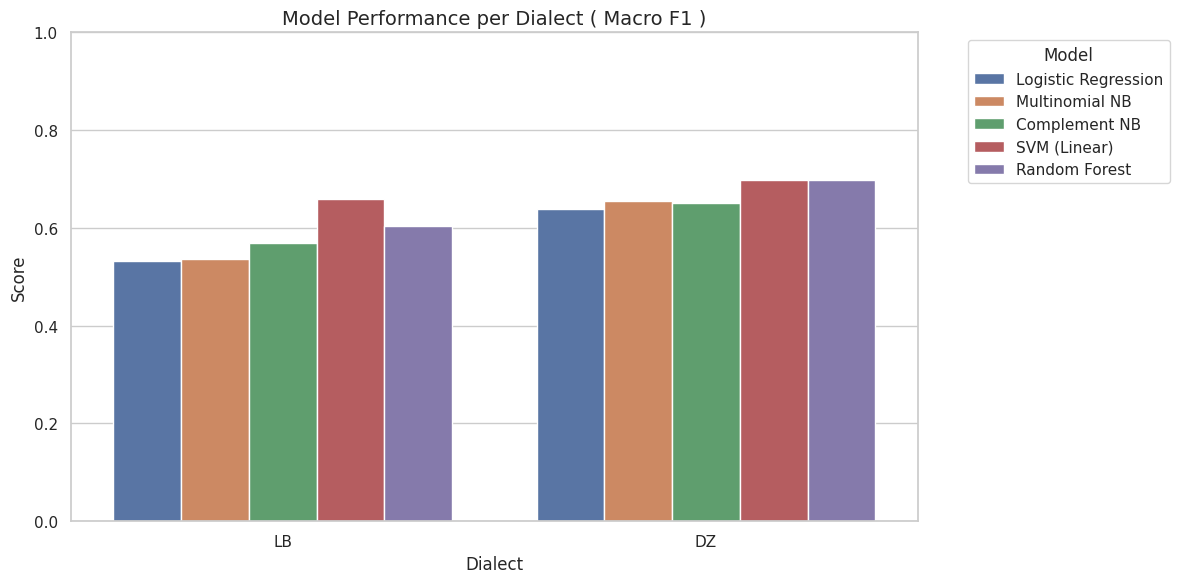

In [ ]:
sns.set(style="whitegrid")

# Melt the DataFrame for easier seaborn plotting
df_melt = df_comparison_dialect.melt(id_vars=["Model","Dialect"],
                                     value_vars=["F1 Macro"],
                                     var_name="Metric",
                                     value_name="Score")

plt.figure(figsize=(12,6))
sns.barplot(data=df_melt, x="Dialect", y="Score", hue="Model", ci=None)

plt.title("Model Performance per Dialect ( Macro F1 )", fontsize=14)
plt.ylabel("Score")
plt.ylim(0,1)
plt.xlabel("Dialect")
plt.legend(title="Model", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


# **PART 03:**

# **DziriBERT Model**

**1. Load DziriBERT Model**

In [ ]:
model_name = "alger-ia/dziribert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at alger-ia/dziribert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**2. Dataset Class**

In [ ]:
label_map = {'non-offensive': 0, 'offensive': 1}

y_train = y_train.map(label_map)
y_val   = y_val.map(label_map)
y_test  = y_test.map(label_map)

print("Train labels:\n", y_train.value_counts())
print("Validation labels:\n", y_val.value_counts())
print("Test labels:\n", y_test.value_counts())


Train labels:
 Generic Class
0    3747
1     977
Name: count, dtype: int64
Validation labels:
 Generic Class
0    938
1    244
Name: count, dtype: int64
Test labels:
 Generic Class
0    1172
1     305
Name: count, dtype: int64


In [ ]:
class ArabiziDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts.tolist(),
            truncation=True,
            padding=True,
            max_length=128
        )
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)


**3. Prepare Datasets**

In [ ]:
train_dataset = ArabiziDataset(X_train, y_train)
val_dataset   = ArabiziDataset(X_val, y_val)
test_dataset  = ArabiziDataset(X_test, y_test)


**4. Define Training Arguments**

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    do_train=True,
    do_eval=True,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    save_steps=500,
    save_total_limit=1
)


**5. Train DziriBERT**

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,   # ✅ validation, not test
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()


/tmp/ipython-input-4059667061.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Step,Training Loss
100,0.432000
200,0.332100
300,0.387700
400,0.425000
500,0.330700
600,0.345900
700,0.272500
800,0.240100
900,0.239900
1000,0.225100


TrainOutput(global_step=2364, training_loss=0.20845021330160537, metrics={'train_runtime': 731.6082, 'train_samples_per_second': 25.828, 'train_steps_per_second': 3.231, 'total_flos': 1242936625520640.0, 'train_loss': 0.20845021330160537, 'epoch': 4.0})

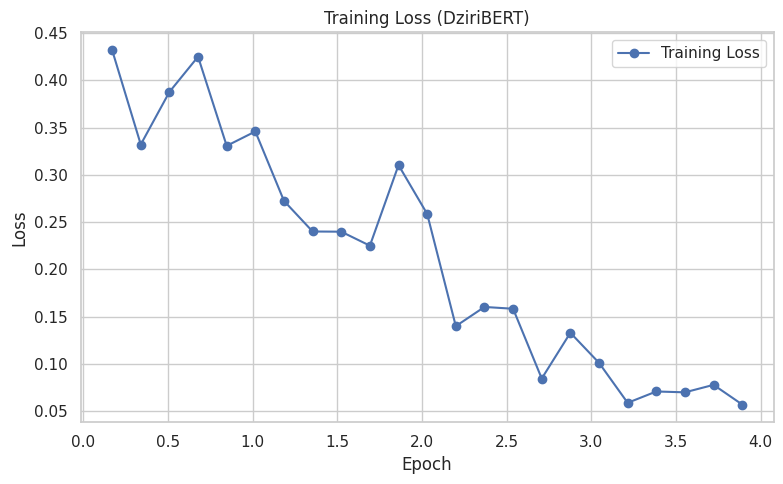

In [ ]:
logs = trainer.state.log_history

train_loss = []
eval_loss = []
epochs = []

for log in logs:
    if "loss" in log and "epoch" in log:
        train_loss.append(log["loss"])
        epochs.append(log["epoch"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])

plt.figure(figsize=(8,5))
plt.plot(epochs[:len(train_loss)], train_loss, label="Training Loss", marker="o")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (DziriBERT)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**6. Evaluate DziriBERT**

In [ ]:
# 1️⃣ Get predictions on TEST
preds_output = trainer.predict(test_dataset)
y_pred_bert = np.argmax(preds_output.predictions, axis=1)

# 2️⃣ Compute metrics
accuracy = accuracy_score(y_test, y_pred_bert)
precision_per_class = precision_score(y_test, y_pred_bert, average=None, zero_division=0)
recall_per_class = recall_score(y_test, y_pred_bert, average=None, zero_division=0)
f1_per_class = f1_score(y_test, y_pred_bert, average=None, zero_division=0)
f1_macro = f1_score(y_test, y_pred_bert, average='macro', zero_division=0)
f1_micro = f1_score(y_test, y_pred_bert, average='micro', zero_division=0)

# 3️⃣ Print detailed classification report
print("=== DziriBERT Classification Report (TEST) ===")
print(classification_report(
    y_test,
    y_pred_bert,
    target_names=["non-offensive", "offensive"],
    zero_division=0
))

# 4️⃣ Print main metrics
print("Accuracy:", accuracy)
print("F1 Macro:", f1_macro)
print("F1 Micro:", f1_micro)

# 5️⃣ Per-class metrics table
metrics_df = pd.DataFrame({
    "Class": ["non-offensive", "offensive"],
    "Precision": precision_per_class,
    "Recall": recall_per_class,
    "F1": f1_per_class
})

metrics_df


=== DziriBERT Classification Report (TEST) ===
               precision    recall  f1-score   support

non-offensive       0.90      0.94      0.92      1172
    offensive       0.74      0.60      0.66       305

     accuracy                           0.87      1477
    macro avg       0.82      0.77      0.79      1477
 weighted avg       0.87      0.87      0.87      1477

Accuracy: 0.8740690589031821
F1 Macro: 0.793379963898917
F1 Micro: 0.8740690589031821


,Class,Precision,Recall,F1
0,non-offensive,0.901466,0.944539,0.92250
1,offensive,0.738956,0.603279,0.66426


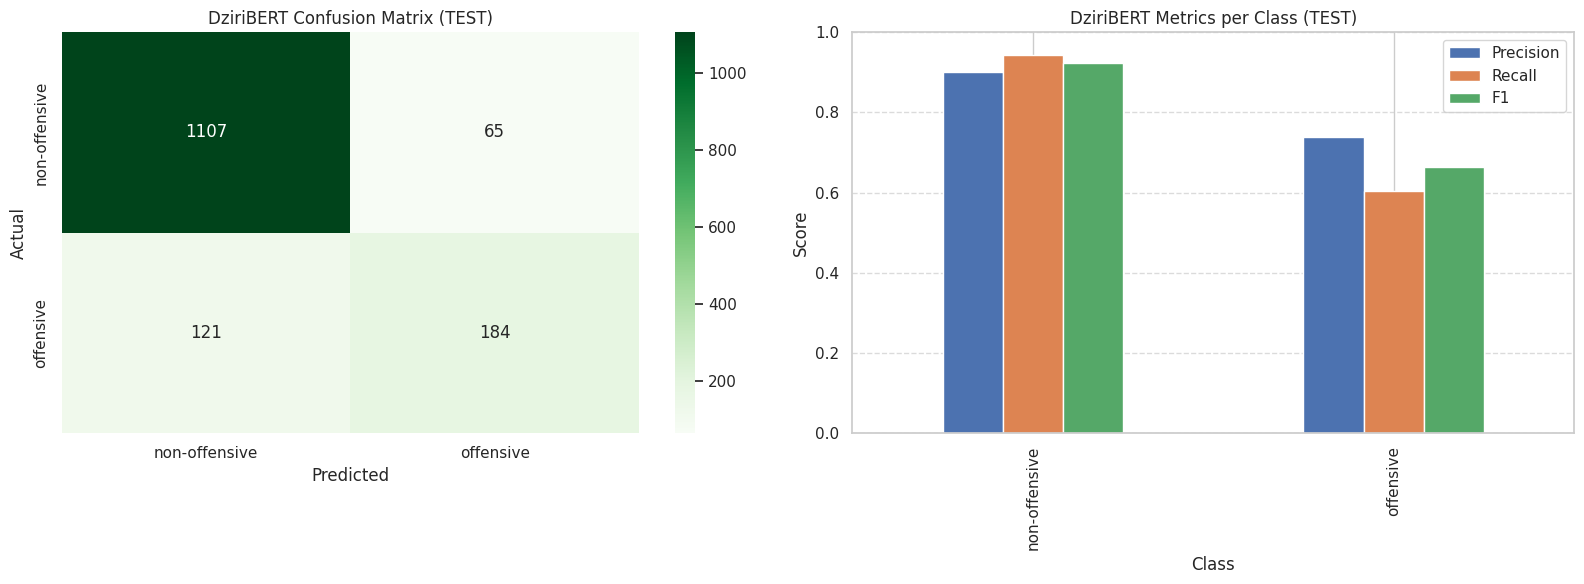

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_bert, labels=[0, 1])

# Per-class metrics
metrics_plot_df = pd.DataFrame({
    "Class": ["non-offensive", "offensive"],
    "Precision": precision_score(y_test, y_pred_bert, average=None, zero_division=0),
    "Recall": recall_score(y_test, y_pred_bert, average=None, zero_division=0),
    "F1": f1_score(y_test, y_pred_bert, average=None, zero_division=0)
}).set_index("Class")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# 1️⃣ Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=["non-offensive", "offensive"],
    yticklabels=["non-offensive", "offensive"],
    ax=axes[0]
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("DziriBERT Confusion Matrix (TEST)")

# 2️⃣ Metrics per Class
metrics_plot_df.plot(kind="bar", ax=axes[1])
axes[1].set_title("DziriBERT Metrics per Class (TEST)")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0,1)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


**7. DziriBERT comparison to classical models**

In [ ]:
comparison_df.loc["DziriBERT (Test)"] = {
    "Accuracy": accuracy,
    "Precision per class": precision_per_class,
    "Recall per class": recall_per_class,
    "F1 per class": f1_per_class,
    "F1 Macro": f1_macro
}

print("=== Comparison Table ===")
comparison_df


=== Comparison Table ===


,Accuracy,Precision per class,Recall per class,F1 per class,F1 Macro
Logistic Regression,0.838409,"[0.8343777976723367, 0.9076923076923077]","[0.9936034115138592, 0.24180327868852458]","[0.9070559610705596, 0.3818770226537217]",0.644466
Multinomial NB,0.841794,"[0.8392050587172538, 0.88]","[0.990405117270789, 0.27049180327868855]","[0.908557457212714, 0.41379310344827586]",0.661175
Complement NB,0.761421,"[0.8951807228915662, 0.4460227272727273]","[0.7921108742004265, 0.6434426229508197]","[0.8404977375565611, 0.5268456375838926]",0.683672
SVM (Linear),0.853638,"[0.8564771668219944, 0.8256880733944955]","[0.9797441364605544, 0.36885245901639346]","[0.9139731476877175, 0.509915014164306]",0.711944
Random Forest,0.844332,"[0.8563327032136105, 0.7419354838709677]","[0.9658848614072495, 0.3770491803278688]","[0.9078156312625251, 0.5]",0.703908
DziriBERT (Test),0.874069,"[0.9014657980456026, 0.7389558232931727]","[0.9445392491467577, 0.6032786885245902]","[0.9225, 0.6642599277978339]",0.79338


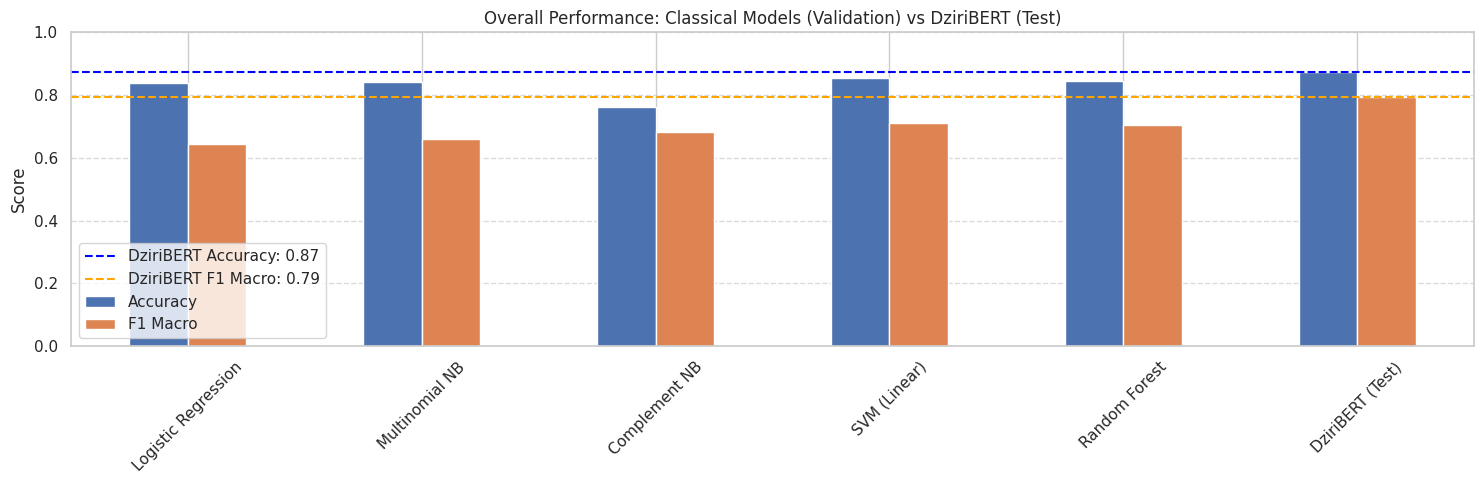

In [ ]:
comparison_plot_df = comparison_df[['Accuracy', 'F1 Macro']].copy()

ax = comparison_plot_df.plot(kind='bar', figsize=(15,5))

accuracy_DB = comparison_plot_df.loc["DziriBERT (Test)", "Accuracy"]
f1_macro_DB = comparison_plot_df.loc["DziriBERT (Test)", "F1 Macro"]

plt.axhline(y=accuracy_DB, color='blue', linestyle='--',
            label=f'DziriBERT Accuracy: {accuracy_DB:.2f}')
plt.axhline(y=f1_macro_DB, color='orange', linestyle='--',
            label=f'DziriBERT F1 Macro: {f1_macro_DB:.2f}')

plt.title("Overall Performance: Classical Models (Validation) vs DziriBERT (Test)")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


**8. DziriBERT metrics per dialect comparison**

In [ ]:
dziri_dialect_metrics = []

for d in dialect_test.unique():
    idx = dialect_test == d
    y_true_d = y_test[idx]
    y_pred_d = y_pred_bert[idx]

    if len(y_true_d) < 10:
        continue

    dziri_dialect_metrics.append({
        "Model": "DziriBERT",
        "Dialect": d,
        "Accuracy": accuracy_score(y_true_d, y_pred_d),
        "F1 Macro": f1_score(y_true_d, y_pred_d, average='macro', zero_division=0),
    })

dziri_dialect_df = pd.DataFrame(dziri_dialect_metrics)

comparison_df_dialect = pd.concat(
    [df_comparison_dialect, dziri_dialect_df],
    ignore_index=True
)

print("=== Comparison per Dialect ===")
comparison_df_dialect


=== Comparison per Dialect ===


,Model,Dialect,Accuracy,F1 Macro
0,Logistic Regression,LB,0.930556,0.533222
1,Logistic Regression,DZ,0.769912,0.639288
2,Multinomial NB,LB,0.934524,0.537061
3,Multinomial NB,DZ,0.772861,0.655256
4,Complement NB,LB,0.886905,0.568175
5,Complement NB,DZ,0.668142,0.650335
6,SVM (Linear),LB,0.940476,0.658321
7,SVM (Linear),DZ,0.789086,0.698941
8,Random Forest,LB,0.926587,0.603158
9,Random Forest,DZ,0.783186,0.698715


/tmp/ipython-input-2191035002.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


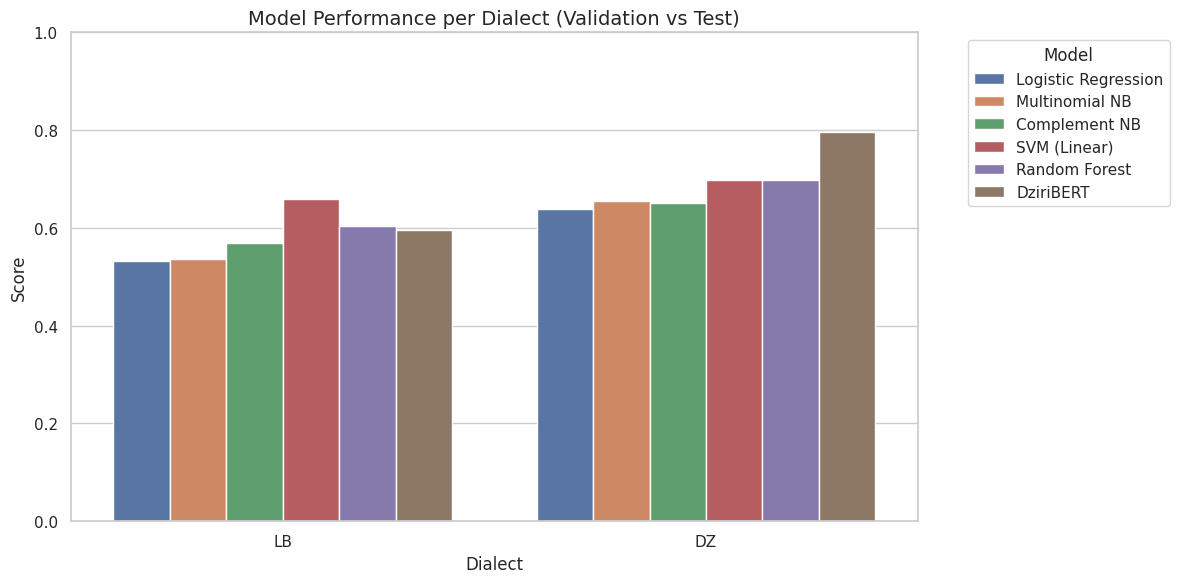

In [ ]:
sns.set(style="whitegrid")

df_melt = comparison_df_dialect.melt(
    id_vars=["Model", "Dialect"],
    value_vars=["F1 Macro"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_melt,
    x="Dialect",
    y="Score",
    hue="Model",
    ci=None
)

plt.title("Model Performance per Dialect (Validation vs Test)", fontsize=14)
plt.ylabel("Score")
plt.ylim(0,1)
plt.xlabel("Dialect")
plt.legend(title="Model", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


# **GPT-style Model (DistilGPT2)**

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# 1️⃣ Choose a larger GPT model
# Options:
# - "gpt2" (small, 124M)
# - "gpt2-medium" (345M)
# - "gpt2-large" (774M)
# - "gpt2-xl" (1.5B)
# - "EleutherAI/gpt-neo-1.3B" (1.3B)
# - "EleutherAI/gpt-neo-2.7B" (2.7B)
# - "EleutherAI/gpt-j-6B" (6B) -> requires GPU with large memory
# Pick one depending on your resources

model_name = "EleutherAI/gpt-neo-1.3B"

# 2️⃣ Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# 3️⃣ Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 4️⃣ GPT models have no pad token by default
tokenizer.pad_token = tokenizer.eos_token

print(f"Using model {model_name} on {device}")


tokenizer_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.31G [00:00<?, ?B/s]

Using model EleutherAI/gpt-neo-1.3B on cuda


In [ ]:
def gpt_zero_shot_predict(text):
    prompt = (
        "Classify the following Arabizi comment as either:\n"
        "- Offensive\n"
        "- Non-Offensive\n\n"
        f"Comment: \"{text}\"\n\n"
        "Answer with only one label:"
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True).lower()

    # Robust decision logic
    if "non-offensive" in decoded:
        return 0
    elif "offensive" in decoded:
        return 1
    else:
        # fallback (optional)
        return 0


In [ ]:
MAX_SAMPLES = 500

texts_test = X_test.iloc[:MAX_SAMPLES].reset_index(drop=True)
y_test_gpt = y_test.iloc[:MAX_SAMPLES].reset_index(drop=True)

y_pred_gpt = []

for text in texts_test:
    pred = gpt_zero_shot_predict(text)
    y_pred_gpt.append(pred)

y_pred_gpt = np.array(y_pred_gpt)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

In [ ]:
accuracy_gpt = accuracy_score(y_test_gpt, y_pred_gpt)
precision_gpt = precision_score(y_test_gpt, y_pred_gpt, average=None, zero_division=0)
recall_gpt = recall_score(y_test_gpt, y_pred_gpt, average=None, zero_division=0)
f1_gpt = f1_score(y_test_gpt, y_pred_gpt, average=None, zero_division=0)
f1_macro_gpt = f1_score(y_test_gpt, y_pred_gpt, average="macro", zero_division=0)
f1_micro_gpt = f1_score(y_test_gpt, y_pred_gpt, average="micro", zero_division=0)

print("=== GPT Zero-Shot Classification Report (TEST SUBSET) ===")
print(classification_report(
    y_test_gpt,
    y_pred_gpt,
    target_names=["non-offensive", "offensive"],
    zero_division=0
))

print("Accuracy:", accuracy_gpt)
print("F1 Macro:", f1_macro_gpt)
print("F1 Micro:", f1_micro_gpt)


=== GPT Zero-Shot Classification Report (TEST SUBSET) ===
               precision    recall  f1-score   support

non-offensive       0.80      1.00      0.89       400
    offensive       0.00      0.00      0.00       100

     accuracy                           0.80       500
    macro avg       0.40      0.50      0.44       500
 weighted avg       0.64      0.80      0.71       500

Accuracy: 0.8
F1 Macro: 0.4444444444444444
F1 Micro: 0.8


In [ ]:
cm_gpt = confusion_matrix(y_test_gpt, y_pred_gpt, labels=[0, 1])

metrics_gpt_df = pd.DataFrame({
    "Class": ["non-offensive", "offensive"],
    "Precision": precision_gpt,
    "Recall": recall_gpt,
    "F1": f1_gpt
}).set_index("Class")

metrics_gpt_df


,Precision,Recall,F1
Class,,,
non-offensive,0.8,1.0,0.888889
offensive,0.0,0.0,0.000000


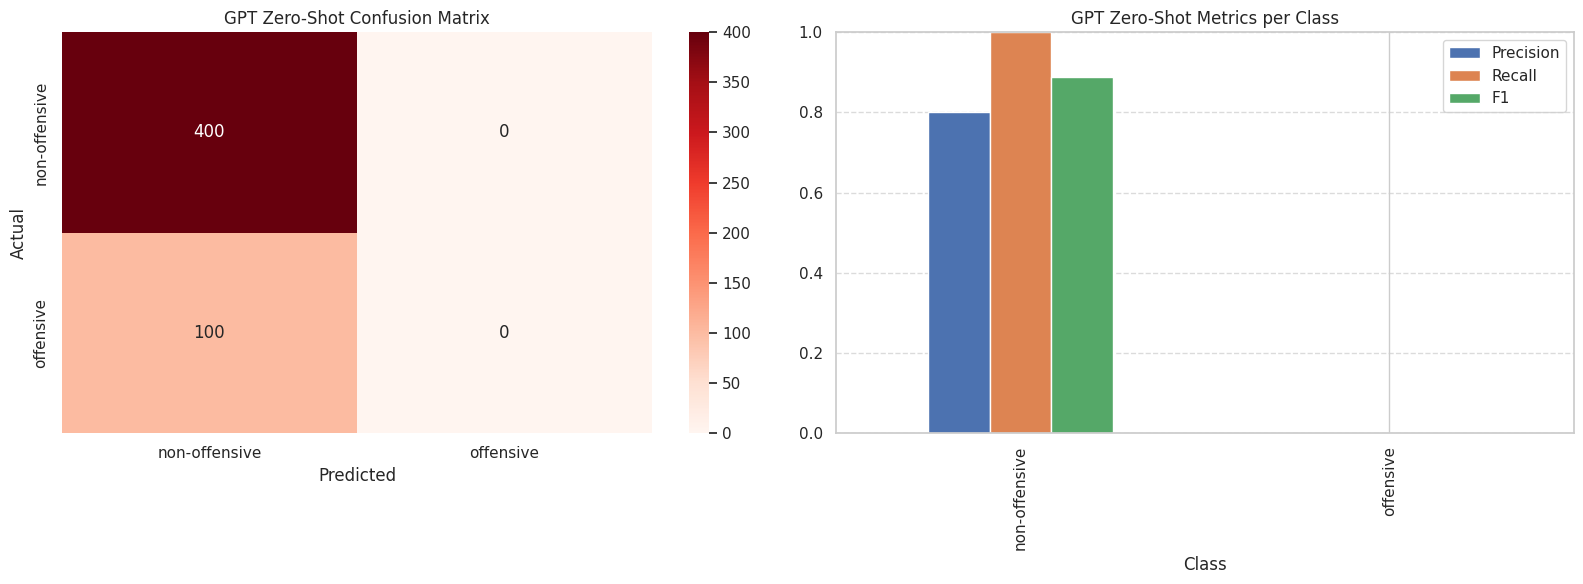

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Confusion Matrix
sns.heatmap(
    cm_gpt,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=list(label_map.keys()),
    yticklabels=list(label_map.keys()),
    ax=axes[0]
)
axes[0].set_title("GPT Zero-Shot Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Metrics Bar Plot
metrics_gpt_df.plot(kind="bar", ax=axes[1])
axes[1].set_title("GPT Zero-Shot Metrics per Class")
axes[1].set_ylim(0,1)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
comparison_df.loc['GPT (Zero-Shot)'] = {
    "Accuracy": accuracy_gpt,
    "Precision per class": precision_gpt,
    "Recall per class": recall_gpt,
    "F1 per class": f1_gpt,
    "F1 Macro": f1_macro_gpt
}

print("=== Updated Comparison Table ===")
comparison_df


=== Updated Comparison Table ===


,Accuracy,Precision per class,Recall per class,F1 per class,F1 Macro
Logistic Regression,0.838409,"[0.8343777976723367, 0.9076923076923077]","[0.9936034115138592, 0.24180327868852458]","[0.9070559610705596, 0.3818770226537217]",0.644466
Multinomial NB,0.841794,"[0.8392050587172538, 0.88]","[0.990405117270789, 0.27049180327868855]","[0.908557457212714, 0.41379310344827586]",0.661175
Complement NB,0.761421,"[0.8951807228915662, 0.4460227272727273]","[0.7921108742004265, 0.6434426229508197]","[0.8404977375565611, 0.5268456375838926]",0.683672
SVM (Linear),0.853638,"[0.8564771668219944, 0.8256880733944955]","[0.9797441364605544, 0.36885245901639346]","[0.9139731476877175, 0.509915014164306]",0.711944
Random Forest,0.844332,"[0.8563327032136105, 0.7419354838709677]","[0.9658848614072495, 0.3770491803278688]","[0.9078156312625251, 0.5]",0.703908
DziriBERT (Test),0.874069,"[0.9014657980456026, 0.7389558232931727]","[0.9445392491467577, 0.6032786885245902]","[0.9225, 0.6642599277978339]",0.79338
GPT (Zero-Shot),0.8,"[0.8, 0.0]","[1.0, 0.0]","[0.8888888888888888, 0.0]",0.444444


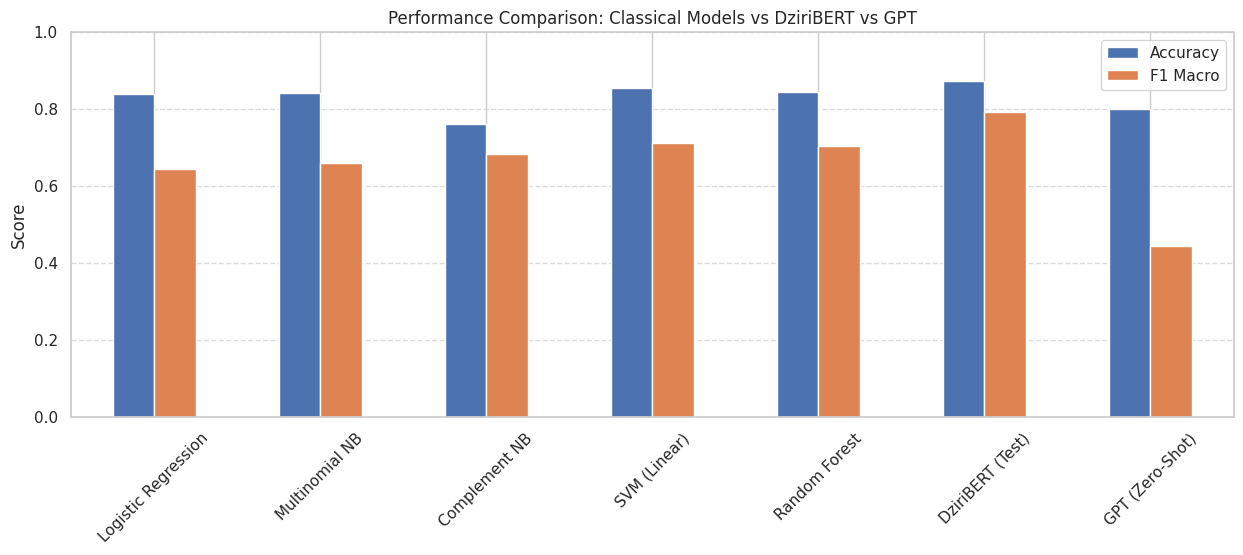

In [ ]:
comparison_plot_df = comparison_df[['Accuracy', 'F1 Macro']]

ax = comparison_plot_df.plot(kind='bar', figsize=(15,5))

plt.title("Performance Comparison: Classical Models vs DziriBERT vs GPT")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()


# **PART 04:**

# **Error Analysis**

**Error Analysis Function**

In [ ]:
def error_analysis_table(
    model_name,
    y_true,
    y_pred,
    texts,
    n_examples=3,
    offensive_label="offensive",
    non_offensive_label="non-offensive"
):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    texts = np.array(texts)

    # False Positive: non-offensive → offensive
    fp_idx = np.where(
        (y_true == non_offensive_label) &
        (y_pred == offensive_label)
    )[0]

    # False Negative: offensive → non-offensive
    fn_idx = np.where(
        (y_true == offensive_label) &
        (y_pred == non_offensive_label)
    )[0]

    # Calculate counts for each class
    non_offensive_count = np.sum(y_true == non_offensive_label)
    offensive_count = np.sum(y_true == offensive_label)
    total = len(y_true)

    # Calculate ratios correctly
    fp_ratio = len(fp_idx) / non_offensive_count if non_offensive_count > 0 else 0
    fn_ratio = len(fn_idx) / offensive_count if offensive_count > 0 else 0

    return {
        "Model": model_name,
        "False Positive Ratio": fp_ratio,  # FP rate: FP / actual negatives
        "False Negative Ratio": fn_ratio,  # FN rate: FN / actual positives
        "FP Count": len(fp_idx),
        "FN Count": len(fn_idx),
        "Total Non-Offensive": non_offensive_count,
        "Total Offensive": offensive_count,
        "Total": total,
        "FP Examples (Non-Off → Off)": texts[fp_idx][:n_examples].tolist(),
        "FN Examples (Off → Non-Off)": texts[fn_idx][:n_examples].tolist()
    }

**Classical models :**

In [ ]:
error_analysis_dialect_results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train_error)
    y_pred = model.predict(X_val_tfidf)
    print(confusion_matrix(y_val_error, y_pred))

    for dialect in dialect_val.unique():
        # Filter by dialect
        idx = dialect_val == dialect

        error_info = error_analysis_table(
            model_name=f"{name} ({dialect})",
            y_true=y_val_error[idx],
            y_pred=y_pred[idx],
            texts=X_val[idx]
        )

        # Add dialect as a column (cleaner than in model name)
        error_info["Model"] = name
        error_info["Dialect"] = dialect

        error_analysis_dialect_results.append(error_info)


[[932   6]
 [185  59]]
[[929   9]
 [178  66]]
[[743 195]
 [ 87 157]]
[[919  19]
 [154  90]]
[[906  32]
 [152  92]]


In [ ]:
error_analysis_dialect_df = pd.DataFrame(error_analysis_dialect_results)

print("=== Error Analysis by Model and Dialect ===")
error_analysis_dialect_df


=== Error Analysis by Model and Dialect ===


,Model,False Positive Ratio,False Negative Ratio,FP Count,FN Count,Total Non-Offensive,Total Offensive,Total,FP Examples (Non-Off → Off),FN Examples (Off → Non-Off),Dialect
0,Logistic Regression,0.004264,0.942857,2,33,469,35,504,"[rouh ya sabe3 ent, wled w beda tel3ab]","[enta ktir beyekh, walla l kezzeb bebayyin awe...",LB
1,Logistic Regression,0.008529,0.727273,4,152,469,209,678,[akhtiha chira marahich barya tahdar m3ak ou n...,"[7na l ke3eb, lazam nwaz3oulham des sac poubel...",DZ
2,Multinomial NB,0.000000,0.942857,0,33,469,35,504,[],"[enta ktir beyekh, walla l kezzeb bebayyin awe...",LB
3,Multinomial NB,0.019190,0.693780,9,145,469,209,678,"[matoub bayna victory hand, hakim annaba, hna ...","[7na l ke3eb, lazam nwaz3oulham des sac poubel...",DZ
4,Complement NB,0.061834,0.800000,29,28,469,35,504,"[guys confession taraket sahebte mberha, bchil...","[enta ktir beyekh, walla l kezzeb bebayyin awe...",LB
5,Complement NB,0.353945,0.282297,166,59,469,209,678,[sayade rajal ou malkache liyougafe mhahe koum...,"[7na l ke3eb, lazam nwaz3oulham des sac poubel...",DZ
6,SVM (Linear),0.006397,0.771429,3,27,469,35,504,"[rouh ya sabe3 ent, lezim nekhod chokair 3and ...","[enta ktir beyekh, walla l kezzeb bebayyin awe...",LB
7,SVM (Linear),0.034115,0.607656,16,127,469,209,678,"[matoub bayna victory hand, hakim annaba, edir...","[7na l ke3eb, lazam nwaz3oulham des sac poubel...",DZ
8,Random Forest,0.017058,0.828571,8,29,469,35,504,[mich enno kalbik kbir laa22 kalba huge w mour...,"[enta ktir beyekh, walla l kezzeb bebayyin awe...",LB
9,Random Forest,0.051173,0.588517,24,123,469,209,678,[menhoum mariam abdelah khadijah etcetcetcetce...,"[7na l ke3eb, lazam nwaz3oulham des sac poubel...",DZ


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=error_analysis_dialect_df)

https://docs.google.com/spreadsheets/d/1bfwuSIxroEgBPgYQ6I5914vccqZHWHihWRyK-N8lSUo/edit#gid=0


**DziriBERT error analysis**

In [ ]:
# First, convert DziriBERT predictions to string labels (already done)
label_map_inv = {0: "non-offensive", 1: "offensive"}
y_pred_bert_str = np.array([label_map_inv[p] for p in y_pred_bert])
y_test_ls = np.array([label_map_inv[p] for p in list(y_test)])

# List to store per-dialect results for DziriBERT
dziri_error_dialect_results = []

for dialect in dialect_test.unique():
    # Filter by dialect
    idx = dialect_test == dialect
    y_true_d = y_test_ls[idx]
    y_pred_d = y_pred_bert_str[idx]
    texts_d = X_test[idx]

    error_info = error_analysis_table(
        model_name="DziriBERT",
        y_true=y_true_d,
        y_pred=y_pred_d,
        texts=texts_d
    )

    # Add model and dialect columns for clarity
    error_info["Model"] = "DziriBERT"
    error_info["Dialect"] = dialect

    dziri_error_dialect_results.append(error_info)

# Convert to DataFrame
dziri_error_dialect_df = pd.DataFrame(dziri_error_dialect_results)

# Append DziriBERT per-dialect analysis to the classical models per-dialect DataFrame
error_analysis_dialect_df = pd.concat(
    [error_analysis_dialect_df, dziri_error_dialect_df],
    ignore_index=True
)

pd.set_option("display.max_colwidth", 150)
print("=== Updated Error Analysis Table by Dialect (Including DziriBERT) ===")
error_analysis_dialect_df


=== Updated Error Analysis Table by Dialect (Including DziriBERT) ===


,Model,False Positive Ratio,False Negative Ratio,FP Count,FN Count,Total Non-Offensive,Total Offensive,Total,FP Examples (Non-Off → Off),FN Examples (Off → Non-Off),Dialect
0,Logistic Regression,0.004264,0.942857,2,33,469,35,504,"[rouh ya sabe3 ent, wled w beda tel3ab]","[enta ktir beyekh, walla l kezzeb bebayyin awem lek adde ma7mou2 ydefi3 3an halo, lak w3aaaaa ya mastoul ya majdoubbbb 3ama chou ma elak 3aazzzzz]",LB
1,Logistic Regression,0.008529,0.727273,4,152,469,209,678,"[akhtiha chira marahich barya tahdar m3ak ou nta tgoulha photo ta3ak tima l adorabele, hada bayen jedo refuge ja f esma roh kawed belibola ok aya ...","[7na l ke3eb, lazam nwaz3oulham des sac poubelle fi sntv maktoub fih khmajak lamou wa dih m3ak, ma3djbkch lhal echki lbabak tebon ya lhas renjas w...",DZ
2,Multinomial NB,0.000000,0.942857,0,33,469,35,504,[],"[enta ktir beyekh, walla l kezzeb bebayyin awem lek adde ma7mou2 ydefi3 3an halo, lak w3aaaaa ya mastoul ya majdoubbbb 3ama chou ma elak 3aazzzzz]",LB
3,Multinomial NB,0.019190,0.693780,9,145,469,209,678,"[matoub bayna victory hand, hakim annaba, hna binatna rasiste alor noirs pur]","[7na l ke3eb, lazam nwaz3oulham des sac poubelle fi sntv maktoub fih khmajak lamou wa dih m3ak, ma3djbkch lhal echki lbabak tebon ya lhas renjas w...",DZ
4,Complement NB,0.061834,0.800000,29,28,469,35,504,"[guys confession taraket sahebte mberha, bchil 5 days forsa, nshala t2t3 3a kheir]","[enta ktir beyekh, walla l kezzeb bebayyin awem lek adde ma7mou2 ydefi3 3an halo, chou beke neuer mouhejim]",LB
5,Complement NB,0.353945,0.282297,166,59,469,209,678,"[sayade rajal ou malkache liyougafe mhahe koumame gale wache rahe fi kalbou marafache, mzya jat andi nationalit fran aise mama zaydtni hih bai khl...","[7na l ke3eb, lazam nwaz3oulham des sac poubelle fi sntv maktoub fih khmajak lamou wa dih m3ak, hhhh ghali 3likk chi]",DZ
6,SVM (Linear),0.006397,0.771429,3,27,469,35,504,"[rouh ya sabe3 ent, lezim nekhod chokair 3and cremino, wled w beda tel3ab]","[enta ktir beyekh, walla l kezzeb bebayyin awem lek adde ma7mou2 ydefi3 3an halo, lak w3aaaaa ya mastoul ya majdoubbbb 3ama chou ma elak 3aazzzzz]",LB
7,SVM (Linear),0.034115,0.607656,16,127,469,209,678,"[matoub bayna victory hand, hakim annaba, edirou kima 1073 lamo ba3dahom w raho l alger manakdrouche andirouha tbanli michha s3iba ! basah adl ann...","[7na l ke3eb, lazam nwaz3oulham des sac poubelle fi sntv maktoub fih khmajak lamou wa dih m3ak, ma3djbkch lhal echki lbabak tebon ya lhas renjas w...",DZ
8,Random Forest,0.017058,0.828571,8,29,469,35,504,"[mich enno kalbik kbir laa22 kalba huge w mour3ebbbb, w er hala2 kenet 3endik, rouh ya sabe3 ent]","[enta ktir beyekh, walla l kezzeb bebayyin awem lek adde ma7mou2 ydefi3 3an halo, lak w3aaaaa ya mastoul ya majdoubbbb 3ama chou ma elak 3aazzzzz]",LB
9,Random Forest,0.051173,0.588517,24,123,469,209,678,"[menhoum mariam abdelah khadijah etcetcetcetcet, hhhhhhhhhhhhhhhhhhhhh ya khii hala yakhiii aaaahh ya zakii wach dakk lamziya to7t fi bent khlak m...","[7na l ke3eb, lazam nwaz3oulham des sac poubelle fi sntv maktoub fih khmajak lamou wa dih m3ak, ma3djbkch lhal echki lbabak tebon ya lhas renjas w...",DZ


**Save to CSV**

In [ ]:
error_analysis_dialect_df.to_csv('error_analysis_dialect.csv', index=False)

/tmp/ipython-input-2140719294.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


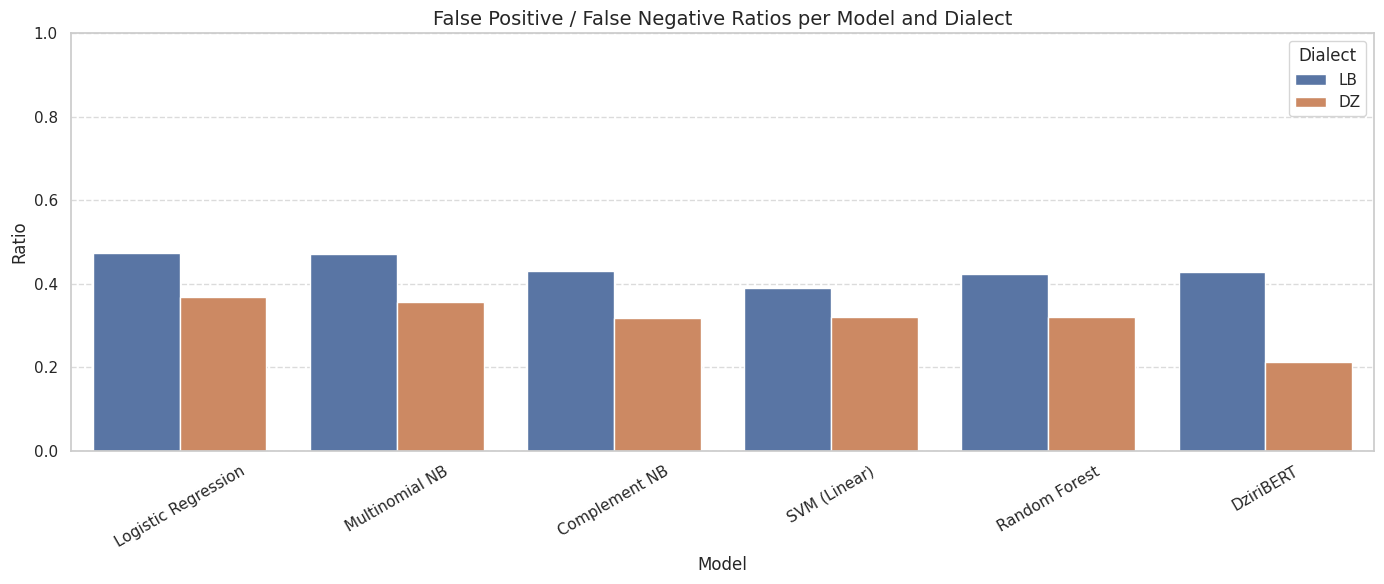

In [ ]:
# Melt the DataFrame to long format for seaborn
df_melt = error_analysis_dialect_df.melt(
    id_vars=["Model", "Dialect"],
    value_vars=["False Positive Ratio", "False Negative Ratio"],
    var_name="Error Type",
    value_name="Ratio"
)

plt.figure(figsize=(14,6))

# Grouped barplot: x=Model, hue=Dialect, y=Ratio, separate bars for FP/FN
sns.barplot(
    data=df_melt,
    x="Model",
    y="Ratio",
    hue="Dialect",
    ci=None
)

plt.title("False Positive / False Negative Ratios per Model and Dialect", fontsize=14)
plt.ylabel("Ratio")
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Dialect")
plt.tight_layout()
plt.show()
